<a href="https://colab.research.google.com/github/harrisariefkamis/PROJECT-DATA-SCIENTIST/blob/main/CASE_STUDY_MODEL_REGRESI_LINEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter-1 MODEL REGRESI LINEAR

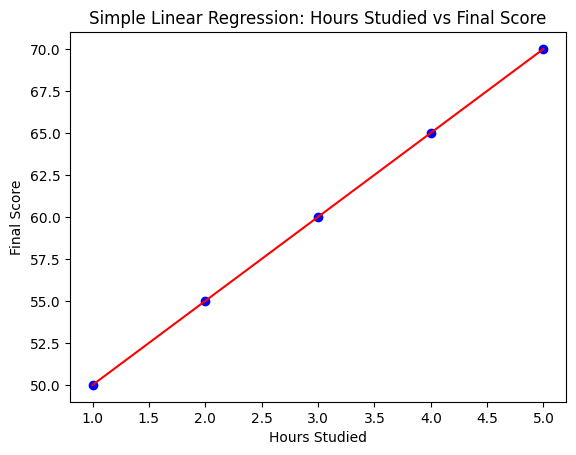

Slope (m): 4.999999999999999
Intercept (b): 45.0
Predicted score for 6 hours of study: 75.0


In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
# Input data
hours_studied = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Independent variable (X)
final_scores = np.array([50, 55, 60, 65, 70])  # Dependent variable (Y)

# Create and fit the model
model = LinearRegression()
model.fit(hours_studied, final_scores)

# Predicting for 6 hours of study
predicted_score = model.predict([[6]])

# Model parameters
slope = model.coef_[0]
intercept = model.intercept_

# Plotting the results
plt.scatter(hours_studied, final_scores, color='blue')
plt.plot(hours_studied, model.predict(hours_studied), color='red')
plt.title('Simple Linear Regression: Hours Studied vs Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.show()

print(f"Slope (m): {slope}")
print(f"Intercept (b): {intercept}")
print(f"Predicted score for 6 hours of study: {predicted_score[0]}")

# Chapter-2 MODEL REGRESI BERGANDA

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
# Create the dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5],
    'Attendance_Rate': [85, 90, 95, 85, 90],
    'Practice_Tests_Taken': [1, 2, 3, 4, 5],
    'Final_Score': [52, 58, 64, 67, 73]
}

# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(data)

# Independent variables (X) and dependent variable (y)
X = df[['Hours_Studied', 'Attendance_Rate', 'Practice_Tests_Taken']]
y = df['Final_Score']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Coefficients and intercept
coefficients = model.coef_
intercept = model.intercept_

# Predict the score for a student who studied 6 hours, attended 95% of classes, and took 6 practice tests
predicted_score = model.predict([[6, 95, 6]])

# Output the coefficients and intercept
print(f"Intercept (b_0): {intercept}")
print(f"Coefficients (b_1, b_2, b_3): {coefficients}")
print(f"Predicted Final Score: {predicted_score[0]}")

Intercept (b_0): 29.99999999999998
Coefficients (b_1, b_2, b_3): [2.5 0.2 2.5]
Predicted Final Score: 79.00000000000001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Visualizing Multiple Linear Regression

To visualize a multiple linear regression model, we can plot the relationship between each independent variable and the dependent variable, while holding other independent variables constant at their mean or median values. This helps understand the individual impact of each feature.

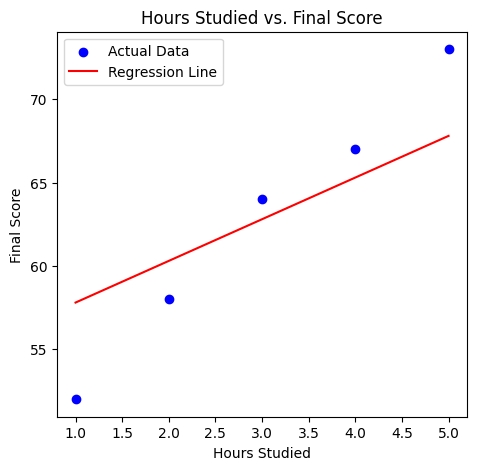

In [3]:
# Calculate mean values for other independent variables to hold them constant
mean_hours_studied = df['Hours_Studied'].mean()
mean_attendance_rate = df['Attendance_Rate'].mean()
mean_practice_tests_taken = df['Practice_Tests_Taken'].mean()

# Plotting Hours_Studied vs. Final_Score (holding others constant)
plt.figure(figsize=(18, 5))

# Plot 1: Hours_Studied vs. Final_Score
plt.subplot(1, 3, 1)
X_hours = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
# Create a DataFrame for prediction, holding other variables at their means
pred_df_hours = pd.DataFrame({
    'Hours_Studied': X_hours,
    'Attendance_Rate': [mean_attendance_rate] * 100,
    'Practice_Tests_Taken': [mean_practice_tests_taken] * 100
})
y_pred_hours = model.predict(pred_df_hours)

plt.scatter(df['Hours_Studied'], df['Final_Score'], color='blue', label='Actual Data')
plt.plot(X_hours, y_pred_hours, color='red', label='Regression Line')
plt.title('Hours Studied vs. Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.legend()

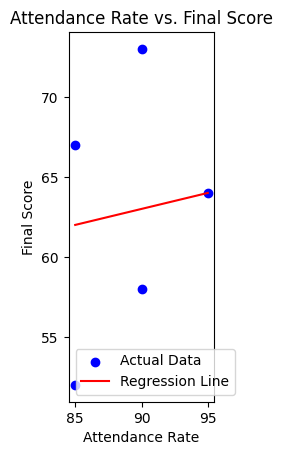

In [4]:
# Plot 2: Attendance_Rate vs. Final_Score
plt.subplot(1, 3, 2)
X_attendance = np.linspace(df['Attendance_Rate'].min(), df['Attendance_Rate'].max(), 100)
# Create a DataFrame for prediction, holding other variables at their means
pred_df_attendance = pd.DataFrame({
    'Hours_Studied': [mean_hours_studied] * 100,
    'Attendance_Rate': X_attendance,
    'Practice_Tests_Taken': [mean_practice_tests_taken] * 100
})
y_pred_attendance = model.predict(pred_df_attendance)

plt.scatter(df['Attendance_Rate'], df['Final_Score'], color='blue', label='Actual Data')
plt.plot(X_attendance, y_pred_attendance, color='red', label='Regression Line')
plt.title('Attendance Rate vs. Final Score')
plt.xlabel('Attendance Rate')
plt.ylabel('Final Score')
plt.legend()

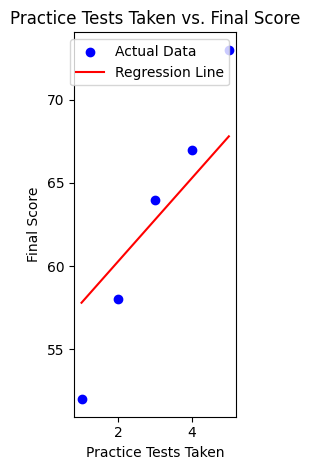

In [5]:
# Plot 3: Practice_Tests_Taken vs. Final_Score
plt.subplot(1, 3, 3)
X_practice = np.linspace(df['Practice_Tests_Taken'].min(), df['Practice_Tests_Taken'].max(), 100)
# Create a DataFrame for prediction, holding other variables at their means
pred_df_practice = pd.DataFrame({
    'Hours_Studied': [mean_hours_studied] * 100,
    'Attendance_Rate': [mean_attendance_rate] * 100,
    'Practice_Tests_Taken': X_practice
})
y_pred_practice = model.predict(pred_df_practice)

plt.scatter(df['Practice_Tests_Taken'], df['Final_Score'], color='blue', label='Actual Data')
plt.plot(X_practice, y_pred_practice, color='red', label='Regression Line')
plt.title('Practice Tests Taken vs. Final Score')
plt.xlabel('Practice Tests Taken')
plt.ylabel('Final Score')
plt.legend()

plt.tight_layout()
plt.show()